In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

print("All imports successful!")


All imports successful!


In [ ]:
netbanking = pd.read_csv(r"C:\Users\Sneha\OneDrive\Desktop\RebuttalAI\Data\netbanking_unauthorized.csv")
upi = pd.read_csv(r"C:\Users\Sneha\OneDrive\Desktop\RebuttalAI\Data\upi_unauthorized.csv")
non_delivery = pd.read_csv(r"C:\Users\Sneha\OneDrive\Desktop\RebuttalAI\Data\non_delivery.csv")
#for trial
print(netbanking.shape)
print(upi.shape)
print(non_delivery.shape)


(1000, 15)
(1200, 15)
(1400, 15)


In [10]:
for name, df in {
    "Netbanking": netbanking,
    "UPI": upi,
    "Non-delivery": non_delivery
}.items():

    print("\n", "="*50)
    print(name)
    print("="*50)

    print(df.info())
    print("\nLabel distribution:")
    print(df["label"].value_counts())



Netbanking
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   case_id                      1000 non-null   str    
 1   reason_code                  1000 non-null   str    
 2   payment_rail                 1000 non-null   str    
 3   order_value                  1000 non-null   float64
 4   days_since_transaction       1000 non-null   int64  
 5   device_ip_match_history      1000 non-null   float64
 6   auth_flow_type               1000 non-null   str    
 7   customer_account_age_days    1000 non-null   int64  
 8   customer_past_order_count    1000 non-null   int64  
 9   customer_past_dispute_count  1000 non-null   int64  
 10  delivery_confirmed           0 non-null      float64
 11  tracking_available           0 non-null      float64
 12  merchant_comm_log_exists     1000 non-null   int64  
 13  refund_already_iss

In [ ]:
for name, df in {
    "Netbanking": netbanking,
    "UPI": upi,
    "Non-delivery": non_delivery
}.items():

    print("\n", "=" * 40)
    print(name)
    print("=" * 40)

    print("Missing values:")
    print(df.isnull().sum()[df.isnull().sum() > 0])
    #the null columns are misleading so dropping these columns


Netbanking
Missing values:
delivery_confirmed    1000
tracking_available    1000
dtype: int64

UPI
Missing values:
delivery_confirmed    1200
tracking_available    1200
dtype: int64

Non-delivery
Missing values:
device_ip_match_history    1400
auth_flow_type             1400
dtype: int64


In [17]:
print("Netbanking:")
print(netbanking.columns.tolist())

print("\nUPI:")
print(upi.columns.tolist())

print("\nNon-delivery:")
print(non_delivery.columns.tolist())


Netbanking:
['case_id', 'reason_code', 'payment_rail', 'order_value', 'days_since_transaction', 'device_ip_match_history', 'auth_flow_type', 'customer_account_age_days', 'customer_past_order_count', 'customer_past_dispute_count', 'merchant_comm_log_exists', 'refund_already_issued', 'label']

UPI:
['case_id', 'reason_code', 'payment_rail', 'order_value', 'days_since_transaction', 'device_ip_match_history', 'auth_flow_type', 'customer_account_age_days', 'customer_past_order_count', 'customer_past_dispute_count', 'merchant_comm_log_exists', 'refund_already_issued', 'label']

Non-delivery:
['case_id', 'reason_code', 'payment_rail', 'order_value', 'days_since_transaction', 'customer_account_age_days', 'customer_past_order_count', 'customer_past_dispute_count', 'delivery_confirmed', 'tracking_available', 'merchant_comm_log_exists', 'refund_already_issued', 'label']


In [18]:
# Features and target

drop_columns = ["case_id", "reason_code", "payment_rail", "label"]

X_netbanking = netbanking.drop(columns=drop_columns)
y_netbanking = netbanking["label"]

X_upi = upi.drop(columns=drop_columns)
y_upi = upi["label"]

X_non_delivery = non_delivery.drop(columns=drop_columns)
y_non_delivery = non_delivery["label"]

In [19]:
print("Netbanking:", X_netbanking.shape, y_netbanking.shape)
print("UPI:", X_upi.shape, y_upi.shape)
print("Non-delivery:", X_non_delivery.shape, y_non_delivery.shape)

Netbanking: (1000, 9) (1000,)
UPI: (1200, 9) (1200,)
Non-delivery: (1400, 9) (1400,)


In [20]:
print("Netbanking features:")
print(X_netbanking.columns.tolist())

print("\nUPI features:")
print(X_upi.columns.tolist())

print("\nNon-delivery features:")
print(X_non_delivery.columns.tolist())

Netbanking features:
['order_value', 'days_since_transaction', 'device_ip_match_history', 'auth_flow_type', 'customer_account_age_days', 'customer_past_order_count', 'customer_past_dispute_count', 'merchant_comm_log_exists', 'refund_already_issued']

UPI features:
['order_value', 'days_since_transaction', 'device_ip_match_history', 'auth_flow_type', 'customer_account_age_days', 'customer_past_order_count', 'customer_past_dispute_count', 'merchant_comm_log_exists', 'refund_already_issued']

Non-delivery features:
['order_value', 'days_since_transaction', 'customer_account_age_days', 'customer_past_order_count', 'customer_past_dispute_count', 'delivery_confirmed', 'tracking_available', 'merchant_comm_log_exists', 'refund_already_issued']


In [ ]:
# Training data and testing data is split in this

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_netbanking,
    y_netbanking,
    test_size=0.20,
    random_state=42,
    stratify=y_netbanking
)

X_train_upi, X_test_upi, y_train_upi, y_test_upi = train_test_split(
    X_upi,
    y_upi,
    test_size=0.20,
    random_state=42,
    stratify=y_upi
)

X_train_nd, X_test_nd, y_train_nd, y_test_nd = train_test_split(
    X_non_delivery,
    y_non_delivery,
    test_size=0.20,
    random_state=42,
    stratify=y_non_delivery
)   

In [22]:
print("Netbanking:", X_train_nb.shape, X_test_nb.shape)
print("UPI:", X_train_upi.shape, X_test_upi.shape)
print("Non-delivery:", X_train_nd.shape, X_test_nd.shape)

Netbanking: (800, 9) (200, 9)
UPI: (960, 9) (240, 9)
Non-delivery: (1120, 9) (280, 9)


In [23]:
# Numerical features

numeric_nb_upi = [
    "order_value",
    "days_since_transaction",
    "device_ip_match_history",
    "customer_account_age_days",
    "customer_past_order_count",
    "customer_past_dispute_count",
    "merchant_comm_log_exists",
    "refund_already_issued"
]

numeric_nd = [
    "order_value",
    "days_since_transaction",
    "customer_account_age_days",
    "customer_past_order_count",
    "customer_past_dispute_count",
    "delivery_confirmed",
    "tracking_available",
    "merchant_comm_log_exists",
    "refund_already_issued"
]

categorical_nb_upi = ["auth_flow_type"]
categorical_nd = []

In [25]:
# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [26]:
# Netbanking preprocessor
preprocessor_nb = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_nb_upi),
        ("cat", categorical_transformer, categorical_nb_upi)
    ]
)

# UPI preprocessor
preprocessor_upi = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_nb_upi),
        ("cat", categorical_transformer, categorical_nb_upi)
    ]
)

# Non-delivery preprocessor
preprocessor_nd = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_nd)
    ]
)

In [ ]:
# Model Pipelines 

In [ ]:
# Netbanking unauthorized dispute

In [ ]:
# ***Logistic Regression pipeline*** 

In [27]:
# Logistic Regression - Netbanking

lr_nb = Pipeline(steps=[
    ("preprocessor", preprocessor_nb),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

# Train the model
lr_nb.fit(X_train_nb, y_train_nb)

print("Netbanking Logistic Regression trained successfully!")

Netbanking Logistic Regression trained successfully!


In [28]:
# Predictions

y_pred_nb = lr_nb.predict(X_test_nb)
y_prob_nb = lr_nb.predict_proba(X_test_nb)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [29]:
# Evaluate the model

accuracy = accuracy_score(y_test_nb, y_pred_nb)
precision = precision_score(y_test_nb, y_pred_nb)
recall = recall_score(y_test_nb, y_pred_nb)
f1 = f1_score(y_test_nb, y_pred_nb)
roc_auc = roc_auc_score(y_test_nb, y_prob_nb)

print("Netbanking - Logistic Regression")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Netbanking - Logistic Regression
--------------------------------
Accuracy : 0.8500
Precision: 0.8870
Recall   : 0.8571
F1 Score : 0.8718
ROC-AUC  : 0.9087


In [ ]:
# ***Random Forest pipeline***

In [30]:
# Random Forest - Netbanking

rf_nb = Pipeline(steps=[
    ("preprocessor", preprocessor_nb),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced",
        min_samples_leaf=2,
        n_jobs=-1
    ))
])

rf_nb.fit(X_train_nb, y_train_nb)

y_pred_rf_nb = rf_nb.predict(X_test_nb)
y_prob_rf_nb = rf_nb.predict_proba(X_test_nb)[:, 1]

print("Netbanking Random Forest trained successfully!")

Netbanking Random Forest trained successfully!


In [31]:
# Evaluate Random Forest

accuracy_rf_nb = accuracy_score(y_test_nb, y_pred_rf_nb)
precision_rf_nb = precision_score(y_test_nb, y_pred_rf_nb)
recall_rf_nb = recall_score(y_test_nb, y_pred_rf_nb)
f1_rf_nb = f1_score(y_test_nb, y_pred_rf_nb)
roc_auc_rf_nb = roc_auc_score(y_test_nb, y_prob_rf_nb)

print("Netbanking - Random Forest")
print("--------------------------")
print(f"Accuracy : {accuracy_rf_nb:.4f}")
print(f"Precision: {precision_rf_nb:.4f}")
print(f"Recall   : {recall_rf_nb:.4f}")
print(f"F1 Score : {f1_rf_nb:.4f}")
print(f"ROC-AUC  : {roc_auc_rf_nb:.4f}")

Netbanking - Random Forest
--------------------------
Accuracy : 0.8600
Precision: 0.8824
Recall   : 0.8824
F1 Score : 0.8824
ROC-AUC  : 0.9109


In [ ]:
# ***XGBoost pipeline***

In [32]:
# XGBoost - Netbanking

xgb_nb = Pipeline(steps=[
    ("preprocessor", preprocessor_nb),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_nb.fit(X_train_nb, y_train_nb)

y_pred_xgb_nb = xgb_nb.predict(X_test_nb)
y_prob_xgb_nb = xgb_nb.predict_proba(X_test_nb)[:, 1]

print("Netbanking XGBoost trained successfully!")

Netbanking XGBoost trained successfully!


In [33]:
# Evaluate XGBoost

accuracy_xgb_nb = accuracy_score(y_test_nb, y_pred_xgb_nb)
precision_xgb_nb = precision_score(y_test_nb, y_pred_xgb_nb)
recall_xgb_nb = recall_score(y_test_nb, y_pred_xgb_nb)
f1_xgb_nb = f1_score(y_test_nb, y_pred_xgb_nb)
roc_auc_xgb_nb = roc_auc_score(y_test_nb, y_prob_xgb_nb)

print("Netbanking - XGBoost")
print("--------------------")
print(f"Accuracy : {accuracy_xgb_nb:.4f}")
print(f"Precision: {precision_xgb_nb:.4f}")
print(f"Recall   : {recall_xgb_nb:.4f}")
print(f"F1 Score : {f1_xgb_nb:.4f}")
print(f"ROC-AUC  : {roc_auc_xgb_nb:.4f}")

Netbanking - XGBoost
--------------------
Accuracy : 0.8350
Precision: 0.8308
Recall   : 0.9076
F1 Score : 0.8675
ROC-AUC  : 0.9073


In [ ]:
# UPI Unauthorized Dispute

In [35]:
upi_df = pd.read_csv("C:\\Users\\Sneha\\OneDrive\\Desktop\\RebuttalAI\\Data\\upi_unauthorized.csv")

upi_df.shape

(1200, 15)

In [36]:
upi_df.head()


,case_id,reason_code,payment_rail,order_value,days_since_transaction,device_ip_match_history,auth_flow_type,customer_account_age_days,customer_past_order_count,customer_past_dispute_count,delivery_confirmed,tracking_available,merchant_comm_log_exists,refund_already_issued,label
0,upi_unauth_00000,upi_unauthorized,upi,3137.73,4,1.000,pin_entry,1051,4,0,NaN,NaN,1,1,1
1,upi_unauth_00001,upi_unauthorized,upi,4253.02,11,0.783,collect_request,1146,5,0,NaN,NaN,0,1,1
2,upi_unauth_00002,upi_unauthorized,upi,2755.82,27,0.907,pin_entry,1318,7,1,NaN,NaN,1,0,1
3,upi_unauth_00003,upi_unauthorized,upi,2467.61,28,1.000,pin_entry,1997,10,1,NaN,NaN,0,0,1
4,upi_unauth_00004,upi_unauthorized,upi,4618.88,11,1.000,collect_request,1518,8,2,NaN,NaN,1,0,1


In [37]:
upi_df['label'].value_counts()

label
1    863
0    337
Name: count, dtype: int64

In [38]:
upi_features = [
    'order_value',
    'days_since_transaction',
    'device_ip_match_history',
    'auth_flow_type',
    'customer_account_age_days',
    'customer_past_order_count',
    'customer_past_dispute_count',
    'merchant_comm_log_exists',
    'refund_already_issued'
]

X_upi = upi_df[upi_features]
y_upi = upi_df['label']

In [39]:
X_train_upi, X_test_upi, y_train_upi, y_test_upi = train_test_split(
    X_upi,
    y_upi,
    test_size=0.20,
    random_state=42,
    stratify=y_upi
)

X_train_upi.shape, X_test_upi.shape

((960, 9), (240, 9))

In [40]:
upi_numeric_features = [
    'order_value',
    'days_since_transaction',
    'device_ip_match_history',
    'customer_account_age_days',
    'customer_past_order_count',
    'customer_past_dispute_count',
    'merchant_comm_log_exists',
    'refund_already_issued'
]
upi_categorical_features = [
    'auth_flow_type'
]

In [41]:
preprocessor_upi = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            upi_numeric_features
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]),
            upi_categorical_features
        )
    ]
)

In [ ]:
# ***Logistic Regression pipeline***

In [42]:
lr_upi = Pipeline([
    ('preprocessor', preprocessor_upi),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

lr_upi.fit(X_train_upi, y_train_upi)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['order_value','days_since_transaction','device_ip_match_history',..., 'customer_past_dispute_count','merchant_comm_log_exists', 'refund_already_issued']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are 

In [43]:
y_pred_lr_upi = lr_upi.predict(X_test_upi)
y_prob_lr_upi = lr_upi.predict_proba(X_test_upi)[:, 1]
print("UPI - Logistic Regression")
print("Accuracy:", accuracy_score(y_test_upi, y_pred_lr_upi))
print("Precision:", precision_score(y_test_upi, y_pred_lr_upi))
print("Recall:", recall_score(y_test_upi, y_pred_lr_upi))
print("F1:", f1_score(y_test_upi, y_pred_lr_upi))
print("ROC-AUC:", roc_auc_score(y_test_upi, y_prob_lr_upi))

UPI - Logistic Regression
Accuracy: 0.8875
Precision: 0.9620253164556962
Recall: 0.8786127167630058
F1: 0.918429003021148
ROC-AUC: 0.937020101803123


In [ ]:
# ***Random Forest pipeline***

In [44]:
rf_upi = Pipeline([
    ('preprocessor', preprocessor_upi),
    ('model', RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight='balanced',
        min_samples_leaf=2,
        n_jobs=-1
    ))
])

rf_upi.fit(X_train_upi, y_train_upi)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['order_value','days_since_transaction','device_ip_match_history',..., 'customer_past_dispute_count','merchant_comm_log_exists', 'refund_already_issued']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are 

In [45]:
y_pred_rf_upi = rf_upi.predict(X_test_upi)
y_prob_rf_upi = rf_upi.predict_proba(X_test_upi)[:, 1]
print("UPI - Random Forest")
print("Accuracy:", accuracy_score(y_test_upi, y_pred_rf_upi))
print("Precision:", precision_score(y_test_upi, y_pred_rf_upi))
print("Recall:", recall_score(y_test_upi, y_pred_rf_upi))
print("F1:", f1_score(y_test_upi, y_pred_rf_upi))
print("ROC-AUC:", roc_auc_score(y_test_upi, y_prob_rf_upi))

UPI - Random Forest
Accuracy: 0.9166666666666666
Precision: 0.9421965317919075
Recall: 0.9421965317919075
F1: 0.9421965317919075
ROC-AUC: 0.9306358381502889


In [ ]:
# ***XGBoost pipeline***

In [46]:
xgb_upi = Pipeline([
    ('preprocessor', preprocessor_upi),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_upi.fit(X_train_upi, y_train_upi)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['order_value','days_since_transaction','device_ip_match_history',..., 'customer_past_dispute_count','merchant_comm_log_exists', 'refund_already_issued']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are 

In [47]:
y_pred_xgb_upi = xgb_upi.predict(X_test_upi)
y_prob_xgb_upi = xgb_upi.predict_proba(X_test_upi)[:, 1]
print("UPI - XGBoost")
print("Accuracy:", accuracy_score(y_test_upi, y_pred_xgb_upi))
print("Precision:", precision_score(y_test_upi, y_pred_xgb_upi))
print("Recall:", recall_score(y_test_upi, y_pred_xgb_upi))
print("F1:", f1_score(y_test_upi, y_pred_xgb_upi))
print("ROC-AUC:", roc_auc_score(y_test_upi, y_prob_xgb_upi))

UPI - XGBoost
Accuracy: 0.9083333333333333
Precision: 0.9217877094972067
Recall: 0.953757225433526
F1: 0.9375
ROC-AUC: 0.9327064101458027


In [ ]:
# Non Delivery unauthorised dispute

In [48]:
nd_df = pd.read_csv(r"C:\Users\Sneha\OneDrive\Desktop\RebuttalAI\Data\non_delivery.csv")

nd_df.shape

(1400, 15)

In [49]:
nd_df['label'].value_counts()

label
1    1067
0     333
Name: count, dtype: int64

In [50]:
nd_features = [
    'order_value',
    'days_since_transaction',
    'customer_account_age_days',
    'customer_past_order_count',
    'customer_past_dispute_count',
    'delivery_confirmed',
    'tracking_available',
    'merchant_comm_log_exists',
    'refund_already_issued'
]

X_nd = nd_df[nd_features]
y_nd = nd_df['label']

In [51]:
X_train_nd, X_test_nd, y_train_nd, y_test_nd = train_test_split(
    X_nd,
    y_nd,
    test_size=0.20,
    random_state=42,
    stratify=y_nd
)

X_train_nd.shape, X_test_nd.shape

((1120, 9), (280, 9))

In [52]:
nd_numeric_features = [
    'order_value',
    'days_since_transaction',
    'customer_account_age_days',
    'customer_past_order_count',
    'customer_past_dispute_count',
    'delivery_confirmed',
    'tracking_available',
    'merchant_comm_log_exists',
    'refund_already_issued'
]

In [53]:
preprocessor_nd = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            nd_numeric_features
        )
    ]
)

In [ ]:
# ***Logistic Regression pipeline***

In [54]:
lr_nd = Pipeline([
    ('preprocessor', preprocessor_nd),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

lr_nd.fit(X_train_nd, y_train_nd)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['order_value','days_since_transaction','customer_account_age_days',..., 'tracking_available','merchant_comm_log_exists','refund_already_issued']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of `

In [55]:
y_pred_lr_nd = lr_nd.predict(X_test_nd)
y_prob_lr_nd = lr_nd.predict_proba(X_test_nd)[:, 1]
print("Non-Delivery - Logistic Regression")
print("Accuracy:", accuracy_score(y_test_nd, y_pred_lr_nd))
print("Precision:", precision_score(y_test_nd, y_pred_lr_nd))
print("Recall:", recall_score(y_test_nd, y_pred_lr_nd))
print("F1:", f1_score(y_test_nd, y_pred_lr_nd))
print("ROC-AUC:", roc_auc_score(y_test_nd, y_prob_lr_nd))

Non-Delivery - Logistic Regression
Accuracy: 0.8428571428571429
Precision: 0.9668508287292817
Recall: 0.8215962441314554
F1: 0.8883248730964467
ROC-AUC: 0.9047018428981851


In [ ]:
# ***Random Forest pipeline***

In [56]:
rf_nd = Pipeline([
    ('preprocessor', preprocessor_nd),
    ('model', RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight='balanced',
        min_samples_leaf=2,
        n_jobs=-1
    ))
])

rf_nd.fit(X_train_nd, y_train_nd)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['order_value','days_since_transaction','customer_account_age_days',..., 'tracking_available','merchant_comm_log_exists','refund_already_issued']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of `

In [57]:
y_pred_rf_nd = rf_nd.predict(X_test_nd)
y_prob_rf_nd = rf_nd.predict_proba(X_test_nd)[:, 1]
print("Non-Delivery - Random Forest")
print("Accuracy:", accuracy_score(y_test_nd, y_pred_rf_nd))
print("Precision:", precision_score(y_test_nd, y_pred_rf_nd))
print("Recall:", recall_score(y_test_nd, y_pred_rf_nd))
print("F1:", f1_score(y_test_nd, y_pred_rf_nd))
print("ROC-AUC:", roc_auc_score(y_test_nd, y_prob_rf_nd))

Non-Delivery - Random Forest
Accuracy: 0.8321428571428572
Precision: 0.9322916666666666
Recall: 0.8403755868544601
F1: 0.8839506172839506
ROC-AUC: 0.8829093966785789


In [ ]:
# ***XGBoost pipeline***

In [58]:
xgb_nd = Pipeline([
    ('preprocessor', preprocessor_nd),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_nd.fit(X_train_nd, y_train_nd)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['order_value','days_since_transaction','customer_account_age_days',..., 'tracking_available','merchant_comm_log_exists','refund_already_issued']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of `

In [59]:
y_pred_xgb_nd = xgb_nd.predict(X_test_nd)
y_prob_xgb_nd = xgb_nd.predict_proba(X_test_nd)[:, 1]
print("Non-Delivery - XGBoost")
print("Accuracy:", accuracy_score(y_test_nd, y_pred_xgb_nd))
print("Precision:", precision_score(y_test_nd, y_pred_xgb_nd))
print("Recall:", recall_score(y_test_nd, y_pred_xgb_nd))
print("F1:", f1_score(y_test_nd, y_pred_xgb_nd))
print("ROC-AUC:", roc_auc_score(y_test_nd, y_prob_xgb_nd))

Non-Delivery - XGBoost
Accuracy: 0.8357142857142857
Precision: 0.8957345971563981
Recall: 0.8873239436619719
F1: 0.8915094339622641
ROC-AUC: 0.8844509845140496


In [60]:
import matplotlib.pyplot as plt

# Creating a dataframe containing the results of all 9 models
comparison_data = [
    # Netbanking
    ["Netbanking", "Logistic Regression", 0.8500, 0.8870, 0.8571, 0.8718],
    ["Netbanking", "Random Forest",       0.8600, 0.8824, 0.8824, 0.8824],
    ["Netbanking", "XGBoost",             0.8350, 0.8308, 0.9076, 0.8675],

    # UPI
    ["UPI", "Logistic Regression", 0.8875, 0.9620, 0.8786, 0.9184],
    ["UPI", "Random Forest",       0.9167, 0.9422, 0.9422, 0.9422],
    ["UPI", "XGBoost",             0.9083, 0.9218, 0.9538, 0.9375],

    # Non-delivery
    ["Non-Delivery", "Logistic Regression", 0.8429, 0.9669, 0.8216, 0.8883],
    ["Non-Delivery", "Random Forest",       0.8321, 0.9323, 0.8404, 0.8840],
    ["Non-Delivery", "XGBoost",             0.8357, 0.8957, 0.8873, 0.8915],
]

comparison_df = pd.DataFrame(
    comparison_data,
    columns=["Dispute Type", "Model", "Accuracy", "Precision", "Recall", "F1"]
)

comparison_df

,Dispute Type,Model,Accuracy,Precision,Recall,F1
0,Netbanking,Logistic Regression,0.8500,0.8870,0.8571,0.8718
1,Netbanking,Random Forest,0.8600,0.8824,0.8824,0.8824
2,Netbanking,XGBoost,0.8350,0.8308,0.9076,0.8675
3,UPI,Logistic Regression,0.8875,0.9620,0.8786,0.9184
4,UPI,Random Forest,0.9167,0.9422,0.9422,0.9422
5,UPI,XGBoost,0.9083,0.9218,0.9538,0.9375
6,Non-Delivery,Logistic Regression,0.8429,0.9669,0.8216,0.8883
7,Non-Delivery,Random Forest,0.8321,0.9323,0.8404,0.8840
8,Non-Delivery,XGBoost,0.8357,0.8957,0.8873,0.8915


In [ ]:
# Plot Accuracy, Precision, Recall and F1 for all 9 models
#Graphical representation for better understanding and finalising the best model for each dispute type

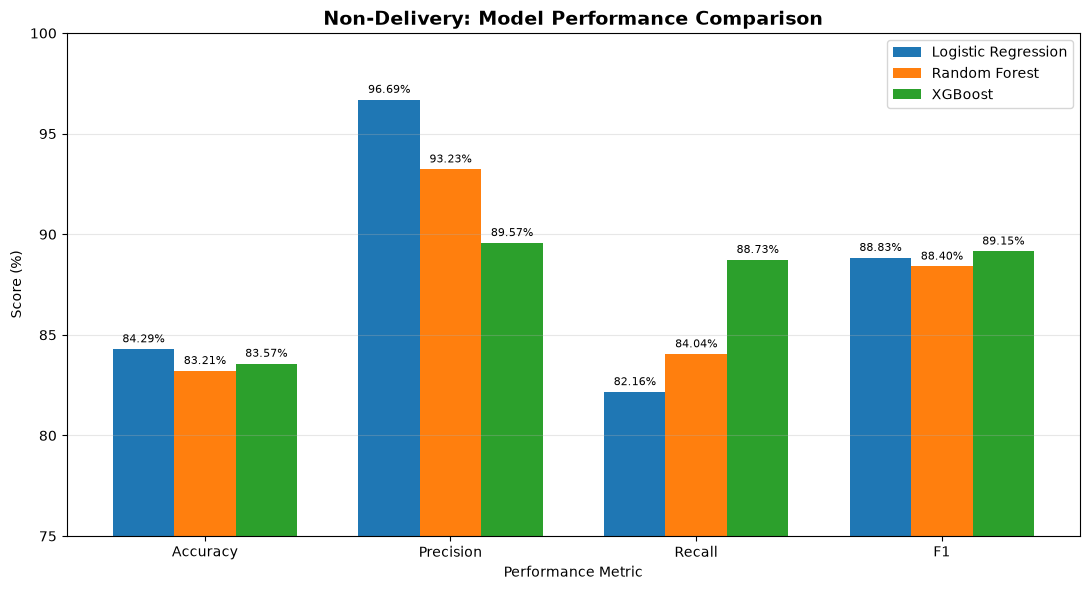

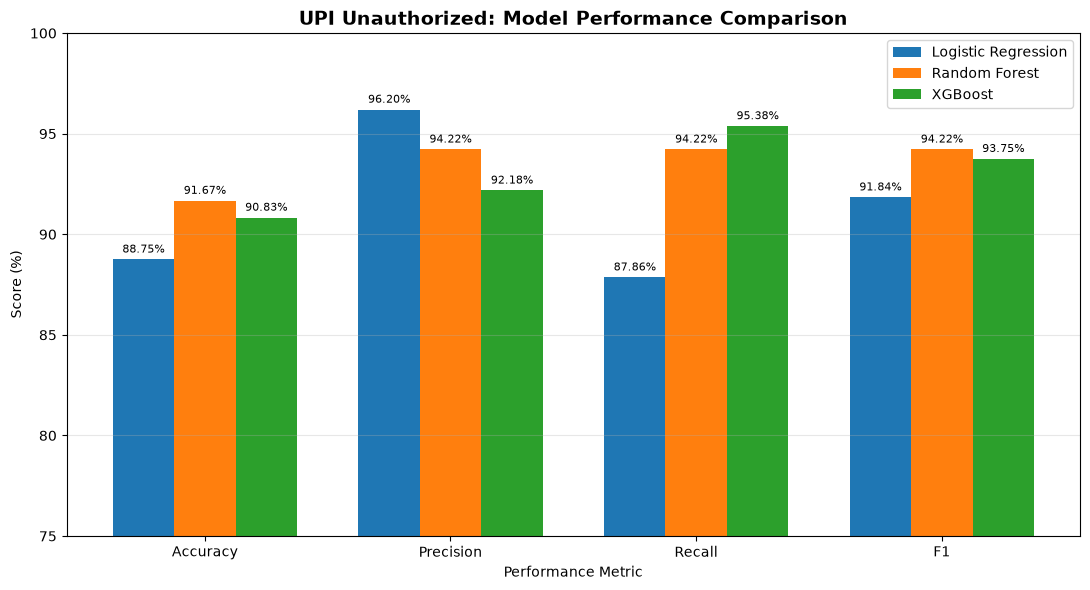

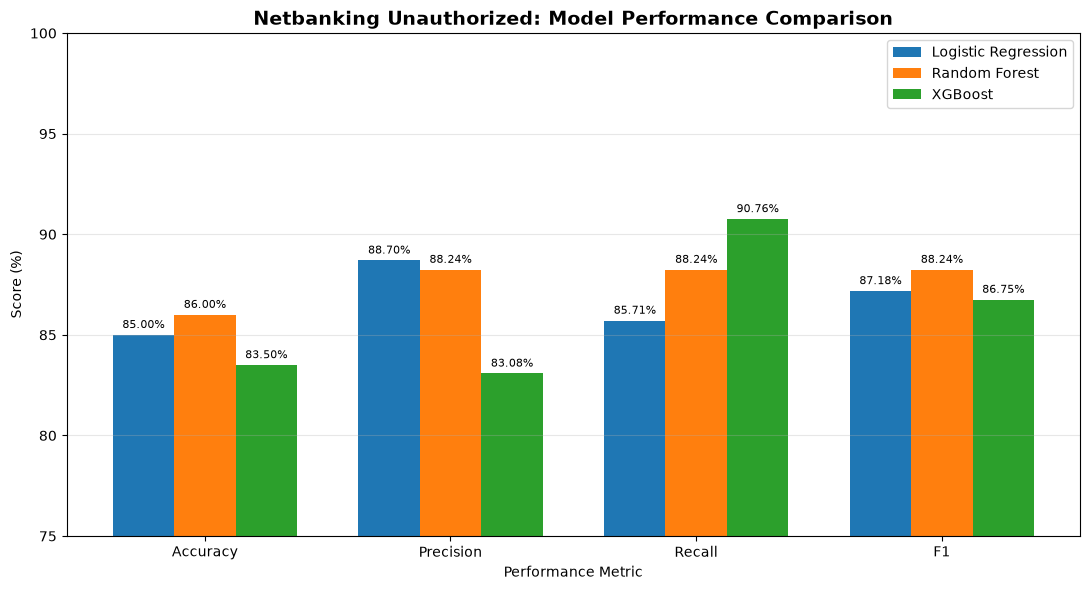

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Model performance results from our evaluation

results = {
    "Non-Delivery": {
        "Logistic Regression": [84.29, 96.69, 82.16, 88.83],
        "Random Forest": [83.21, 93.23, 84.04, 88.40],
        "XGBoost": [83.57, 89.57, 88.73, 89.15]
    },

    "UPI Unauthorized": {
        "Logistic Regression": [88.75, 96.20, 87.86, 91.84],
        "Random Forest": [91.67, 94.22, 94.22, 94.22],
        "XGBoost": [90.83, 92.18, 95.38, 93.75]
    },

    "Netbanking Unauthorized": {
        "Logistic Regression": [85.00, 88.70, 85.71, 87.18],
        "Random Forest": [86.00, 88.24, 88.24, 88.24],
        "XGBoost": [83.50, 83.08, 90.76, 86.75]
    }
}

metrics = ["Accuracy", "Precision", "Recall", "F1"]
models = ["Logistic Regression", "Random Forest", "XGBoost"]

# Create one graph for each dispute type
for dispute_type, model_results in results.items():

    x = np.arange(len(metrics))
    width = 0.25

    fig, ax = plt.subplots(figsize=(11, 6))

    for i, model in enumerate(models):
        values = model_results[model]

        bars = ax.bar(
            x + (i - 1) * width,
            values,
            width,
            label=model
        )

        # Display percentage on top of each bar
        ax.bar_label(
            bars,
            fmt="%.2f%%",
            padding=3,
            fontsize=8
        )

    ax.set_title(
        f"{dispute_type}: Model Performance Comparison",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Performance Metric")
    ax.set_ylabel("Score (%)")

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)

    ax.set_ylim(75, 100)

    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# ROC-AUC comparison for all 9 models

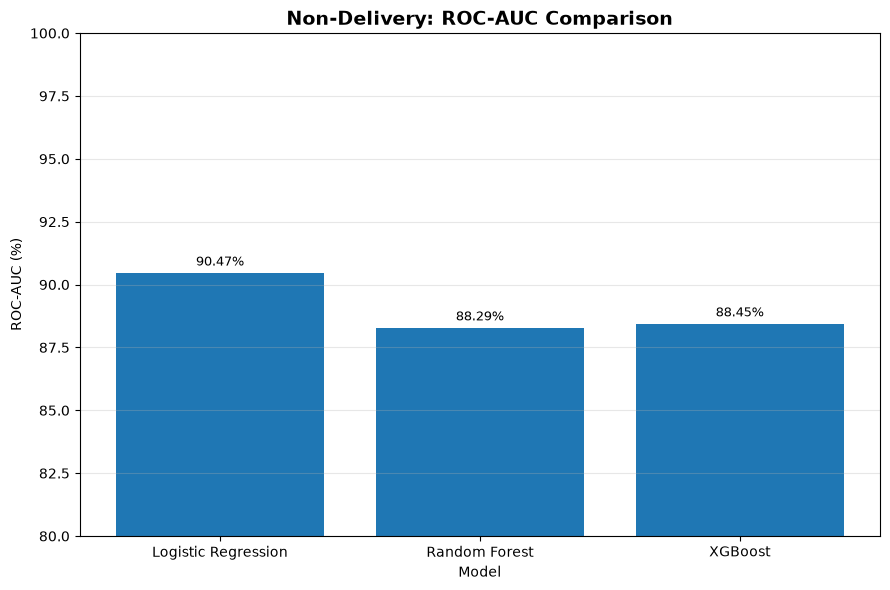

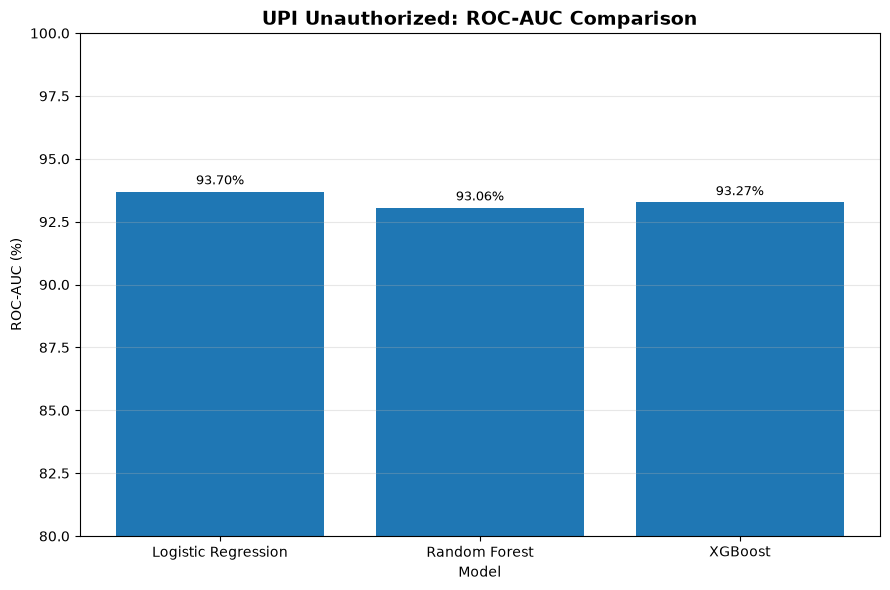

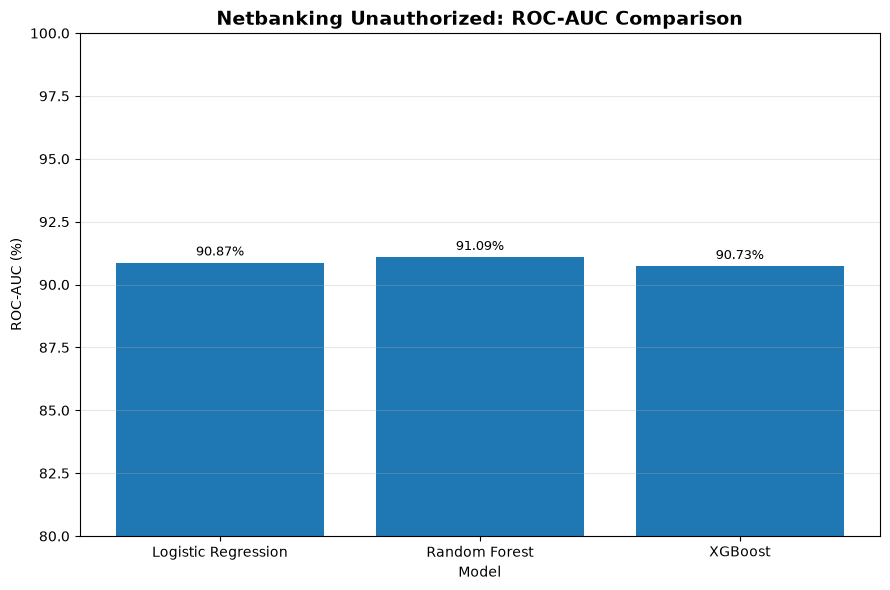

In [64]:
# ROC-AUC comparison

roc_auc_results = {
    "Non-Delivery": {
        "Logistic Regression": 90.47,
        "Random Forest": 88.29,
        "XGBoost": 88.45
    },

    "UPI Unauthorized": {
        "Logistic Regression": 93.70,
        "Random Forest": 93.06,
        "XGBoost": 93.27
    },

    "Netbanking Unauthorized": {
        "Logistic Regression": 90.87,
        "Random Forest": 91.09,
        "XGBoost": 90.73
    }
}

for dispute_type, model_results in roc_auc_results.items():

    models = list(model_results.keys())
    scores = list(model_results.values())

    plt.figure(figsize=(9, 6))

    bars = plt.bar(models, scores)

    plt.title(
        f"{dispute_type}: ROC-AUC Comparison",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel("Model")
    plt.ylabel("ROC-AUC (%)")
    plt.ylim(80, 100)

    # Add values above bars
    plt.bar_label(
        bars,
        fmt="%.2f%%",
        padding=3,
        fontsize=9
    )

    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# Confusion Matrix for the best model of each dispute type

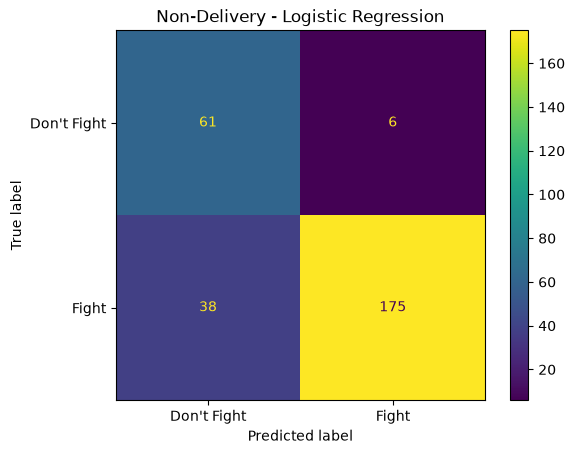

In [67]:
cm_nd_lr = confusion_matrix(y_test_nd, y_pred_lr_nd)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nd_lr,
    display_labels=["Don't Fight", "Fight"]
)

disp.plot()
plt.title("Non-Delivery - Logistic Regression")
plt.show()

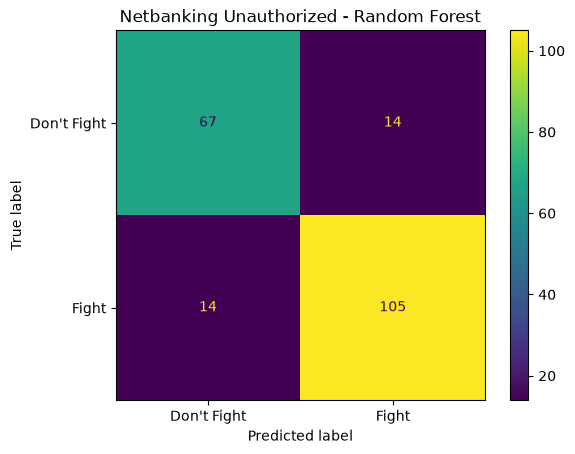

In [68]:
cm_nb_rf = confusion_matrix(y_test_nb, y_pred_rf_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb_rf,
    display_labels=["Don't Fight", "Fight"]
)

disp.plot()
plt.title("Netbanking Unauthorized - Random Forest")
plt.show()

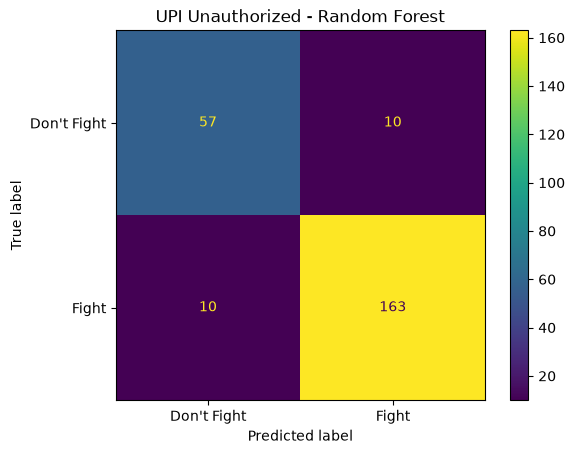

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_upi_rf = confusion_matrix(y_test_upi, y_pred_rf_upi)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_upi_rf,
    display_labels=["Don't Fight", "Fight"]
)

disp.plot()
plt.title("UPI Unauthorized - Random Forest")
plt.show()